# Low-ℓ BB — Manual Tile Inspector

Inspect raw unmasked patches first, choose a mask, then compare masked patches.

**To switch Stokes component**: change `STOKES_KEY` (T / Q / U) in Paths, re-run from Load map down.

In [1]:
import os
import sys
import numpy as np
import healpy as hp
import matplotlib
import matplotlib.pyplot as plt
from spt3g import core, maps
from astropy.io import fits
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _here = os.getcwd()
sys.path.insert(0, _here)

from Plot import (
    apply_spt_style,
    mask_map,
    show_map_full_field,
    show_map_thumbnail,
)

apply_spt_style()

#### Paths

In [3]:
# Stokes selector
# Change to "Q" or "U" and re-run from §2 to inspect a different component.
STOKES_KEY = "U"

# Map STOKES_KEY to FITS field index (0=T, 1=Q, 2=U)
_STOKES_FIELD = {"T": 0, "Q": 1, "U": 2}
assert STOKES_KEY in _STOKES_FIELD, f"STOKES_KEY must be T / Q / U, got '{STOKES_KEY}'"

# Data paths
DATA_DIR   = "/sptgrid/analysis/spt3g_d1_midell_tqu_healpix"
# DATA_DIR = '/sptgrid/user/javva/baseline_bb_coadd_match/coadd_fullauto/full/no_signflip_bundle_000.g3.gz"
COADD_PATH = os.path.join(DATA_DIR, "real_data_maps", "full")

full_220ghz = os.path.join(COADD_PATH, "full_220ghz.fits")
full_150ghz = os.path.join(COADD_PATH, "full_150ghz.fits")
full_095ghz = os.path.join(COADD_PATH, "full_095ghz.fits")

# Active frequency — change to full_150ghz or full_095ghz to switch band
COADD_FILE = full_220ghz

# Mask directory
MASK_DIR = "/sptlocal/user/creichardt/bb2020"

# Available masks
MASK_FILES = {
    "mask_250_30"   : "puremask8192_0p5medwt_250mJy_30arcmin.npz",
    "mask_250_60"   : "puremask8192_0p5medwt_250mJy_60arcmin.npz",
    "mask_250_nd30" : "puremask8192_0p5medwt_250mJy_nodisk_30arcmin.npz",
    "mask_250_nd60" : "puremask8192_0p5medwt_250mJy_nodisk_60arcmin.npz",
    "mask_100_30"   : "puremask8192_0p5medwt_100mJy_30arcmin.npz",
    "mask_apod_30"  : "puremask8192_0p5medwt_30arcmin.npz",
    "mask_apod_60"  : "puremask8192_0p5medwt_60arcmin.npz",
}

# Output directory
SAVE_DIR = "/sptlocal/user/vwelke/lowl_bb_tiles"
os.makedirs(SAVE_DIR, exist_ok=True)

# Display parameters
RESO_ARCMIN = 0.5
PATCH_DEG   = 15.0
PATCH_PIX   = int(PATCH_DEG * 60 / RESO_ARCMIN)  # pixels per side
CMAP        = "coolwarm"

print(f"Stokes key  : {STOKES_KEY}  (FITS field index {_STOKES_FIELD[STOKES_KEY]})")
print(f"Active file : {os.path.basename(COADD_FILE)}")
print(f"Patch size  : {PATCH_DEG}° × {PATCH_DEG}°  =  {PATCH_PIX} × {PATCH_PIX} px")
print(f"Resolution  : {RESO_ARCMIN} arcmin/px")

Stokes key  : U  (FITS field index 2)
Active file : full_220ghz.fits
Patch size  : 15.0° × 15.0°  =  1800 × 1800 px
Resolution  : 0.5 arcmin/px


#### Load map

In [4]:
# Load only the selected Stokes component 
field_idx  = _STOKES_FIELD[STOKES_KEY]
stokes_arr = hp.read_map(COADD_FILE, field=field_idx, partial=False)

nside = hp.get_nside(stokes_arr)
print(f"Loaded     : {STOKES_KEY}  from  {os.path.basename(COADD_FILE)}")
print(f"nside      : {nside}")
print(f"Total pix  : {len(stokes_arr):,}")

Loaded     : U  from  full_220ghz.fits
nside      : 8192
Total pix  : 805,306,368


#### Observed-pixel mask

In [5]:
obs_mask = np.isfinite(stokes_arr) & (stokes_arr != hp.UNSEEN)

obs_pix        = np.where(obs_mask)[0]
theta_c, phi_c = hp.pix2ang(nside, obs_pix)
ra_obs  = np.degrees(phi_c)
ra_obs  = np.where(ra_obs > 180, ra_obs - 360, ra_obs)   # shift to [-180, 180]
dec_obs = 90.0 - np.degrees(theta_c)

ra_min,  ra_max  = ra_obs.min(),  ra_obs.max()
dec_min, dec_max = dec_obs.min(), dec_obs.max()

print(f"Observed pixels  : {obs_mask.sum():,}  ({obs_mask.sum()/len(stokes_arr)*100:.2f}% of sky)")
print(f"RA  range  :  {ra_min:.2f}° → {ra_max:.2f}°   span = {ra_max-ra_min:.2f}°")
print(f"Dec range  : {dec_min:.2f}° → {dec_max:.2f}°   span = {dec_max-dec_min:.2f}°")

Observed pixels  : 36,557,509  (4.54% of sky)
RA  range  :  -56.51° → 53.76°   span = 110.28°
Dec range  : -71.98° → -40.20°   span = 31.78°


#### Tile grid

In [6]:
ra_centres  = np.arange(ra_min  + PATCH_DEG/2, ra_max  + PATCH_DEG/2, PATCH_DEG)
dec_centres = np.arange(dec_min + PATCH_DEG/2, dec_max + PATCH_DEG/2, PATCH_DEG)

n_ra, n_dec = len(ra_centres), len(dec_centres)
print(f"RA  centres  : {n_ra}   [{ra_centres[0]:.1f}° … {ra_centres[-1]:.1f}°]")
print(f"Dec centres  : {n_dec}   [{dec_centres[0]:.1f}° … {dec_centres[-1]:.1f}°]")
print(f"Total patches : {n_ra * n_dec}")
print()
print("RA_IDX  →  RA centre")
for i, r in enumerate(ra_centres):
    print(f"  {i}  →  {r:+.1f}°")
print()
print("DEC_IDX  →  Dec centre")
for j, d in enumerate(dec_centres):
    print(f"  {j}  →  {d:+.1f}°")

RA  centres  : 8   [-49.0° … 56.0°]
Dec centres  : 3   [-64.5° … -34.5°]
Total patches : 24

RA_IDX  →  RA centre
  0  →  -49.0°
  1  →  -34.0°
  2  →  -19.0°
  3  →  -4.0°
  4  →  +11.0°
  5  →  +26.0°
  6  →  +41.0°
  7  →  +56.0°

DEC_IDX  →  Dec centre
  0  →  -64.5°
  1  →  -49.5°
  2  →  -34.5°


#### Unmasked patches

Inspect the raw map first — spot bright point sources, decide which mask to use below.

In [7]:
# Choose patch
#   RA_IDX  : 0 … n_ra-1   (west → east)
#   DEC_IDX : 0 … n_dec-1  (south → north)
RA_IDX  = 5
DEC_IDX = 1

ra_c  = ra_centres[RA_IDX]
dec_c = dec_centres[DEC_IDX]
print(f"Patch ({RA_IDX}, {DEC_IDX})  →  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°")

Patch (5, 1)  →  RA +26.0°  Dec -49.5°


In [8]:
# Plot (unmasked)
rms        = float(np.std(stokes_arr[obs_mask]))
vmin, vmax = -rms, rms

#show_map_thumbnail(
#    stokes_arr,
#    vmin=vmin, vmax=vmax,
#    title=(
#        f"{STOKES_KEY}  unmasked  |  patch ({RA_IDX}, {DEC_IDX})  "
#        f"|  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°"
#    ),
#    unit="Tcmb", cmap=CMAP,
#    rot=(ra_c, dec_c, 0),
#    xsize=PATCH_PIX, ysize=PATCH_PIX,
#    reso=RESO_ARCMIN,
#)
#plt.show()

In [9]:
# Zoom in — unmasked
# Change ZOOM_DEG to adjust zoom level
#ZOOM_DEG = 3.0
#ZOOM_PIX = int(ZOOM_DEG * 60 / RESO_ARCMIN)

#show_map_thumbnail(
#    stokes_arr,
#    vmin=vmin, vmax=vmax,
#    title=f"{STOKES_KEY}  unmasked  zoom {ZOOM_DEG}°  |  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°",
#    unit="Tcmb", cmap=CMAP,
#    rot=(ra_c, dec_c, 0),
#    xsize=ZOOM_PIX, ysize=ZOOM_PIX,
#    reso=RESO_ARCMIN,
#)
#plt.show()

In [10]:
# Close
plt.close("all")

#### Load mask

After inspecting the raw patches above, choose a mask from `MASK_FILES` and run this cell.

In [16]:
# Choose mask
# Available keys (defined in §1):
#   mask_250_30   — 250 mJy point-source mask, 30 arcmin apodisation
#   mask_250_60   — 250 mJy point-source mask, 60 arcmin apodisation
#   mask_250_nd30 — 250 mJy, no disk, 30 arcmin
#   mask_250_nd60 — 250 mJy, no disk, 60 arcmin
#   mask_100_30   — 100 mJy point-source mask, 30 arcmin
#   mask_apod_30  — apodisation only, 30 arcmin (no source masking)
#   mask_apod_60  — apodisation only, 60 arcmin (no source masking)
ACTIVE_MASK = "mask_250_nd30"

mask_path = os.path.join(MASK_DIR, MASK_FILES[ACTIVE_MASK])
with np.load(mask_path) as d:
    apod     = d[d.files[0]].astype(float)
    mask_key = d.files[0]

nside_mask = hp.get_nside(apod)
if nside_mask != nside:
    print(f"Upgrading mask from nside={nside_mask} → nside={nside}")
    apod = hp.ud_grade(apod, nside_out=nside)

obs_and_mask = obs_mask & (apod > 0)

# Apply apodisation weight
stokes_masked                 = stokes_arr.copy()
stokes_masked[obs_and_mask]  *= apod[obs_and_mask]
stokes_masked[~obs_and_mask]  = hp.UNSEEN

print(f"Mask loaded  : {ACTIVE_MASK}")
print(f"File         : {MASK_FILES[ACTIVE_MASK]}")
print(f"key='{mask_key}'  |  nside={hp.get_nside(apod)}")
print(f"Pixels after mask : {obs_and_mask.sum():,}  (was {obs_mask.sum():,} unmasked)")

Mask loaded  : mask_250_nd30
File         : puremask8192_0p5medwt_250mJy_nodisk_30arcmin.npz
key='mask'  |  nside=8192
Pixels after mask : 33,271,247  (was 36,557,509 unmasked)


#### Masked patches

Same `RA_IDX` / `DEC_IDX` as above — easy before/after comparison.

In [17]:
# Choose patch
#   Same RA_IDX / DEC_IDX as §5 for direct before/after comparison
RA_IDX  = 5
DEC_IDX = 1

ra_c  = ra_centres[RA_IDX]
dec_c = dec_centres[DEC_IDX]
print(f"Patch ({RA_IDX}, {DEC_IDX})  →  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°")

Patch (5, 1)  →  RA +26.0°  Dec -49.5°


In [18]:
# Plot (masked)
#rms        = float(np.std(stokes_masked[obs_and_mask]))
#vmin, vmax = -3*rms, 3*rms

#show_map_thumbnail(
#    stokes_masked,
#    vmin=vmin, vmax=vmax,
#    title=(
#        f"{STOKES_KEY}  masked ({ACTIVE_MASK})  |  patch ({RA_IDX}, {DEC_IDX})  "
#        f"|  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°"
#    ),
#    unit="Tcmb", cmap=CMAP,
#    rot=(ra_c, dec_c, 0),
#    xsize=PATCH_PIX, ysize=PATCH_PIX,
#    reso=RESO_ARCMIN,
#)
#plt.show()

In [27]:
# Load the .txt containing the source catalogue
# Path: /home/creichardt/spt3g_software/sources/mask_lists/high_ell_TT_2021_1500d_source_mask_6mJy_plusedges.txt

source_path = "/home/creichardt/spt3g_software/sources/mask_lists/"
source_file = os.path.join(source_path, "high_ell_TT_2021_1500d_source_mask_6mJy_plusedges.txt")

with open(source_file) as f:
    print(f.read())

# Derived from spt3g_1500d_source_list_ma_21dec21_v1.txt, and
# spt3g_1500d_winter_edge_source_list_tc_21jul22.txt (for sources
# outside the nominal region) Sources are selected above 6 mJy, and
# radius is set using source_utils.determine_masking_radius with
# threshold=1 mJy.  All sources in the edges are masked with a 5
# arcmin radius.


"index"	"RA(deg)"	"DEC(deg)"	"radius"	"S150(mJy)"
0	1.03127	-43.7525	0.00049451	47.0492398186
1	29.46335	-46.23895	0.0005526876	68.8448893015
2	-30.00315	-47.86492	0.0005526876	63.9436860393
3	14.19209	-44.85019	0.0005526876	64.843385699
4	-7.97615	-41.29597	0.0006108652	75.8471022353
5	-39.05122	-47.22136	0.0006108652	82.0809803757
6	-10.91111	-43.62947	0.0005526876	72.1697910958
7	-2.10337	-42.99225	0.0006108652	83.1909703474
8	-10.22129	-42.1129	0.0005526876	71.4688395837
9	49.49112	-44.23781	0.0006108652	75.8239649972
10	2.29164	-46.21897	0.0006108652	87.1237771956
11	11.56901	-42.12647	0.0006108652	78.0459655879
12	-1.70396	-48.10014	0.000610

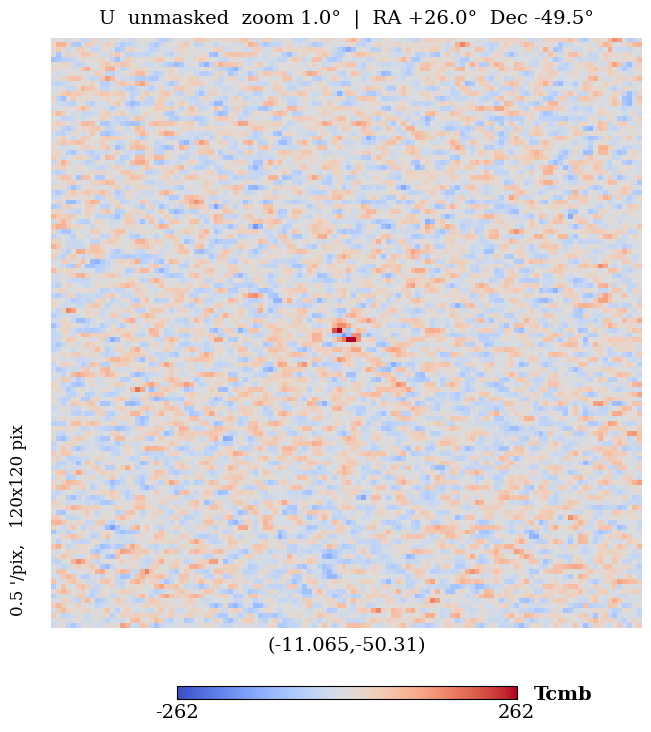

In [43]:
# zoom in unmasked
ZOOM_DEG = 1.0
ZOOM_PIX = int(ZOOM_DEG * 60 / RESO_ARCMIN)

show_map_thumbnail(
    stokes_arr,
    vmin=vmin, vmax=vmax,
    title=f"{STOKES_KEY}  unmasked  zoom {ZOOM_DEG}°  |  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°",
    unit="Tcmb", cmap=CMAP,
    rot=(-11.06532, -50.3103, 0),
    xsize=ZOOM_PIX, ysize=ZOOM_PIX,
    reso=RESO_ARCMIN,
)
plt.show()


In [44]:
plt.close("all")

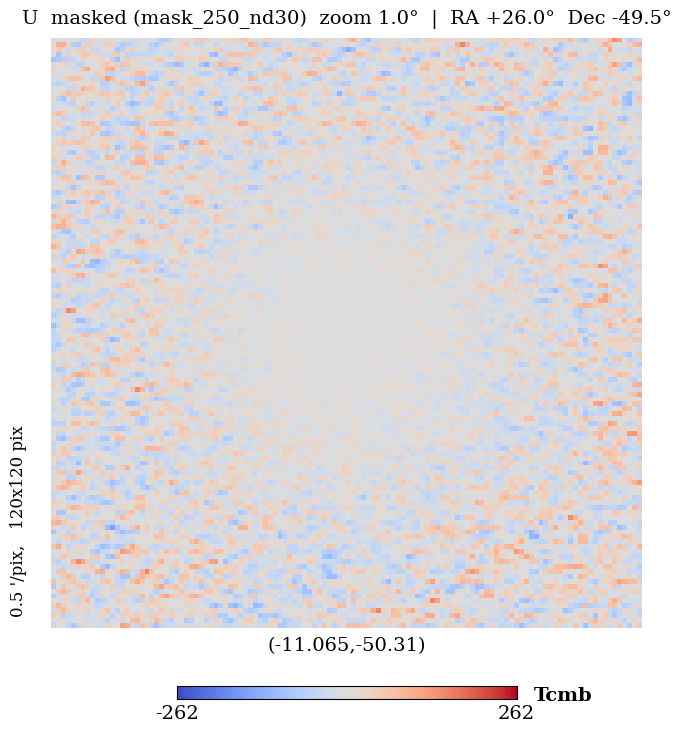

In [45]:
# Zoom in — masked
# Change ZOOM_DEG to adjust zoom level
ZOOM_DEG = 1.0
ZOOM_PIX = int(ZOOM_DEG * 60 / RESO_ARCMIN)

show_map_thumbnail(
    stokes_masked,
    vmin=vmin, vmax=vmax,
    title=f"{STOKES_KEY}  masked ({ACTIVE_MASK})  zoom {ZOOM_DEG}°  |  RA {ra_c:+.1f}°  Dec {dec_c:+.1f}°",
    unit="Tcmb", cmap=CMAP,
    rot=(-11.06532, -50.3103, 0),
    xsize=ZOOM_PIX, ysize=ZOOM_PIX,
    reso=RESO_ARCMIN,
)
plt.show()

In [42]:
# Close
plt.close("all")

#### Power spectrum (draft)

> Draft only — no beam correction, no mode-coupling / purification.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("/sptlocal/user/vwelke/lowl_bb_tiles/noise_psd_BB_fits_220ghz.npz")
ell = data['ell']
N_l = data['N_l']

plt.figure(figsize=(8, 6))
plt.plot(ell, N_l)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$N_\ell^{BB}$")
plt.title(f"BB noise power spectrum (mask={data['mask']}, N={data['N']})")
plt.yscale('log')   # noise spectra often span orders of magnitude
plt.tight_layout()
plt.show()

**Open question:** what to store alongside `N_l`?
- Just the `ell` array + `N_l` (noise Cl) as a pair?
- Or also the signal `C_l` from the coadd map, so both can be plotted together?
- Or the raw `a_lm` coefficients from each sign-flip map for later use?

In [ ]:
# Save C_ell to FITS — uncomment when ready
# out_cl = os.path.join(SAVE_DIR, f"cl_{STOKES_KEY}_{ACTIVE_MASK}.fits")
# hp.write_cl(out_cl, cl, overwrite=True)
# print(f"C_ell saved → {out_cl}")